# Project Deliverable 3: Classification, Clustering, and Pattern Mining

## Assignment 
This deliverable builds two classification models, tunes one model, evaluates with confusion matrix, ROC curve, accuracy, and F1 score, creates a clustering model, and applies association rule mining.

In [1]:
from pathlib import Path
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

SCREENSHOTS=Path('screenshots'); SCREENSHOTS.mkdir(exist_ok=True)
wine=pd.read_csv('data/winequality-red-cleaned-project-d1.csv')
wine['quality_class'] = (wine['quality'] >= 6).astype(int)
print(wine['quality_class'].value_counts())
wine.head()

quality_class
1    719
0    640
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_class
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


In [2]:
X=wine.drop(columns=['quality','quality_class'])
y=wine['quality_class']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

classifiers={
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'k-NN': Pipeline([('scaler', StandardScaler()),('model', KNeighborsClassifier(n_neighbors=7))])
}
rows=[]
for name,clf in classifiers.items():
    clf.fit(X_train,y_train)
    pred=clf.predict(X_test)
    rows.append({'model':name,'accuracy':accuracy_score(y_test,pred),'f1':f1_score(y_test,pred)})
results=pd.DataFrame(rows).round(4)
results

,model,accuracy,f1
0,Decision Tree,0.6801,0.6947
1,k-NN,0.6985,0.7230


In [3]:
param_grid={'model__n_neighbors':[3,5,7,9,11], 'model__weights':['uniform','distance']}
knn_pipe=Pipeline([('scaler', StandardScaler()),('model', KNeighborsClassifier())])
grid=GridSearchCV(knn_pipe,param_grid,cv=5,scoring='f1')
grid.fit(X_train,y_train)
print('Best k-NN parameters:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_,4))
tuned_knn=grid.best_estimator_
pred=tuned_knn.predict(X_test)
print('Tuned k-NN accuracy:', round(accuracy_score(y_test,pred),4))
print('Tuned k-NN F1:', round(f1_score(y_test,pred),4))

Best k-NN parameters: {'model__n_neighbors': 11, 'model__weights': 'distance'}
Best CV F1: 0.7649
Tuned k-NN accuracy: 0.7279
Tuned k-NN F1: 0.7448


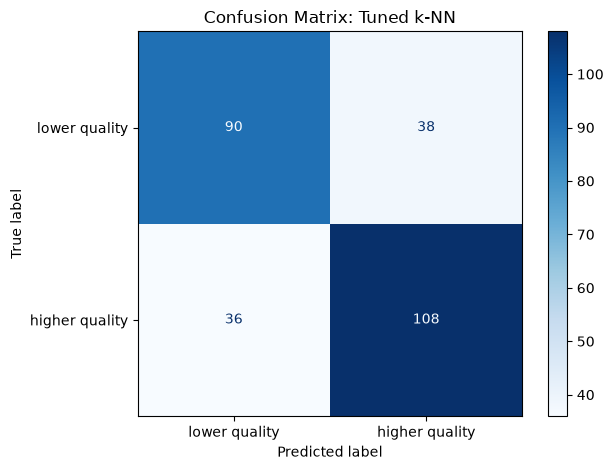

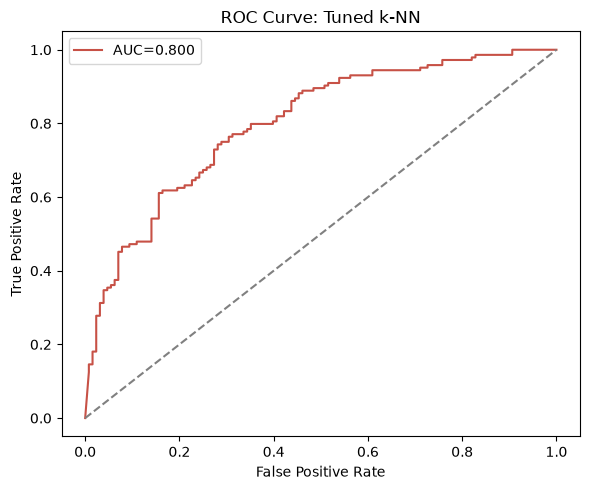

In [4]:
cm=confusion_matrix(y_test,pred)
disp=ConfusionMatrixDisplay(cm, display_labels=['lower quality','higher quality'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Tuned k-NN')
plt.tight_layout()
plt.savefig(SCREENSHOTS/'d3_confusion_matrix.png', dpi=160)
plt.show()

probs=tuned_knn.predict_proba(X_test)[:,1]
fpr,tpr,_=roc_curve(y_test,probs)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f'AUC={roc_auc:.3f}', color='#c75146')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Tuned k-NN')
plt.legend()
plt.tight_layout()
plt.savefig(SCREENSHOTS/'d3_roc_curve.png', dpi=160)
plt.show()

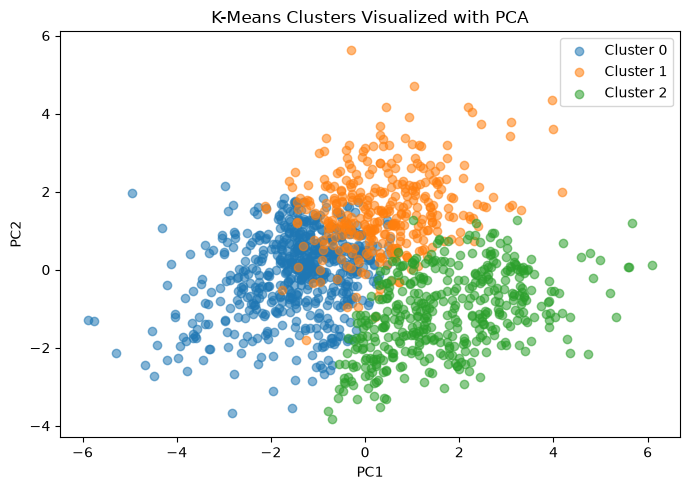

,quality,alcohol,volatile acidity,sulphates
cluster,,,,
0,5.537,10.557,0.608,0.606
1,5.316,9.815,0.551,0.627
2,5.991,10.759,0.403,0.730


In [5]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
kmeans=KMeans(n_clusters=3, random_state=42, n_init=20)
clusters=kmeans.fit_predict(X_scaled)
pca=PCA(n_components=2, random_state=42)
coords=pca.fit_transform(X_scaled)
cluster_df=pd.DataFrame({'PC1':coords[:,0],'PC2':coords[:,1],'cluster':clusters,'quality':wine['quality'],'alcohol':wine['alcohol']})
plt.figure(figsize=(7,5))
for c in sorted(cluster_df['cluster'].unique()):
    subset=cluster_df[cluster_df['cluster']==c]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {c}', alpha=0.55)
plt.title('K-Means Clusters Visualized with PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig(SCREENSHOTS/'d3_kmeans_clusters.png', dpi=160)
plt.show()
cluster_summary=wine.assign(cluster=clusters).groupby('cluster')[['quality','alcohol','volatile acidity','sulphates']].mean().round(3)
cluster_summary

In [6]:
# Simple association rule mining using discretized wine properties.
items=pd.DataFrame(index=wine.index)
items['high_quality'] = wine['quality'] >= 6
items['high_alcohol'] = wine['alcohol'] >= wine['alcohol'].quantile(.75)
items['low_volatile_acidity'] = wine['volatile acidity'] <= wine['volatile acidity'].quantile(.25)
items['high_sulphates'] = wine['sulphates'] >= wine['sulphates'].quantile(.75)
items['low_density'] = wine['density'] <= wine['density'].quantile(.25)

def support(cols):
    return items[list(cols)].all(axis=1).mean()

rules=[]
features=[c for c in items.columns if c!='high_quality']
for antecedent_size in [1,2]:
    for antecedent in itertools.combinations(features, antecedent_size):
        ant_sup=support(antecedent)
        both_sup=support(antecedent+('high_quality',))
        consequent_sup=support(('high_quality',))
        confidence=both_sup/ant_sup if ant_sup else 0
        lift=confidence/consequent_sup if consequent_sup else 0
        rules.append({'antecedent':' + '.join(antecedent),'consequent':'high_quality','support':both_sup,'confidence':confidence,'lift':lift})
rules_df=pd.DataFrame(rules).sort_values(['lift','confidence'], ascending=False).round(3)
rules_df.head(10)

,antecedent,consequent,support,confidence,lift
9,high_sulphates + low_density,high_quality,0.061,0.954,1.803
5,high_alcohol + high_sulphates,high_quality,0.085,0.928,1.754
4,high_alcohol + low_volatile_acidity,high_quality,0.096,0.915,1.730
8,low_volatile_acidity + low_density,high_quality,0.078,0.883,1.670
6,high_alcohol + low_density,high_quality,0.146,0.861,1.627
7,low_volatile_acidity + high_sulphates,high_quality,0.094,0.853,1.613
0,high_alcohol,high_quality,0.222,0.846,1.599
1,low_volatile_acidity,high_quality,0.194,0.754,1.426
2,high_sulphates,high_quality,0.185,0.730,1.381
3,low_density,high_quality,0.188,0.729,1.377


## Interpretation
The classification models translate quality into a practical higher/lower quality decision. The tuned k-NN model can help screen wines likely to receive higher quality scores, but performance should be interpreted cautiously because chemical measures do not fully capture taste evaluation. K-means clustering reveals groups of wines with different alcohol, acidity, and sulphate profiles. Association rules make the patterns more interpretable, showing which combinations of high alcohol, low volatile acidity, high sulphates, or low density tend to align with higher quality.

In [7]:
results.to_csv('data/d3_classification_results.csv', index=False)
cluster_summary.to_csv('data/d3_cluster_summary.csv')
rules_df.to_csv('data/d3_association_rules.csv', index=False)
print('Saved classification, clustering, and association rule outputs.')

Saved classification, clustering, and association rule outputs.
